# accDM limit / reduction tests

Checks that the implementation collapses to known physics in the limits where it must. Two limits are genuinely clean ΛCDM reductions:

- **`f_acc -> 0`**: no accelerating component at all, so background / C_l / P(k) must approach ΛCDM, with the deviation scaling ~linearly in `f_acc`.
- **`eta -> 0`**: the daughter is produced with no momentum kick (`P_acc = m_cdm*sqrt(eta(eta+2)) -> 0`), i.e. cold. A cold daughter converted from cold parent is indistinguishable from CDM, so observables must approach ΛCDM as `eta` shrinks.

**Note on `a_t` (why it is *not* a limit test here):** the parent density carries a `(1 - a^kappa)` factor, so it always fully converts by `a = 1` *regardless of `a_t`* - `a_t` only sets *when* conversion happens. So neither `a_t -> 0` nor `a_t -> inf` recovers ΛCDM, and there is no `a_t` reduction to assert.

Shared neutrino sector: one massive-neutrino ncdm species (deg 3, m = 0.02 eV) plus `N_ur = 0.00441`, identical between the ΛCDM reference and the accDM runs, so the only difference is the accDM species itself.

Hybrid output: hard asserts (nbmake/pytest catch failures) + convergence plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

LMAX = 2500
K_NODES = np.logspace(-3, 0.7, 40)   # 1/Mpc, for P(k) comparison

# ---- Planck 2018 base cosmology ----------------------------------
omega_b    = 0.022383
omega_cdm0 = 0.12011
A_s        = 2.1005829616811546e-9
n_s        = 0.96605
tau_reio   = 0.0543
H0         = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

# light precision: no lensing (raw C_l), modest WDM bin count -> fast
PREC = {'output': 'tCl,pCl,mPk', 'l_max_scalars': LMAX,
        'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0}

# fiducial accDM knobs held fixed while one limit parameter varies
A_T   = 0.13
KAPPA = 12.0
MASS  = 1e16          # GeV (parent == daughter)
A_REC = 1.0 / (1.0 + 1090.0)

def lcdm_params():
    p = dict(base_params); p.update(PREC)
    p.update({'N_ncdm': 1, 'deg_ncdm': 3, 'm_ncdm': 0.02, 'T_ncdm': 0.71611,
              'ncdm_quadrature_strategy': 3, 'ncdm_N_momentum_bins': 30, 'ncdm_fluid_approximation': 0,
              'N_ur': 0.00441, 'evolver': 0, 'background_Nloga': 2500})
    return p

def accdm_params(f_acc, eta):
    # rescale CDM so total CDM(+acc) is fixed at recombination (bg_tests_w_Q convention)
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '3, 4',
              'ncdm_N_momentum_bins': '30, 301', 'N_ur': 0.00441,
              'reionization_z_start_max': 80, 'evolver': 0, 'background_Nloga': 2500, "ncdm_fluid_approximation": "3, 3"})
    return p

_cache = {}
def run_obs(params, key):
    if key in _cache:
        return _cache[key]
    M = Class(); M.set(params); M.compute()
    cl = M.raw_cl(LMAX)
    obs = {'ell': np.asarray(cl['ell']), 'tt': np.asarray(cl['tt']),
           'pk': np.array([M.pk(float(k), 0.0) for k in K_NODES]),
           'sigma8': float(M.sigma8())}
    M.struct_cleanup(); M.empty()
    _cache[key] = obs
    return obs

def maxnorm(cur, ref):
    s = np.max(np.abs(ref)); s = s if s > 0 else 1.0
    return float(np.max(np.abs(np.asarray(cur) - np.asarray(ref))) / s)

def relmax(cur, ref):
    ref = np.asarray(ref, float); cur = np.asarray(cur, float)
    return float(np.max(np.abs(cur - ref) / np.where(np.abs(ref) > 0, np.abs(ref), 1.0)))

def deviation(o, ref):
    m = o['ell'] >= 2
    return {'cl_tt': maxnorm(o['tt'][m], ref['tt'][m]),
            'pk':    relmax(o['pk'], ref['pk']),
            'sigma8': abs(o['sigma8'] - ref['sigma8']) / ref['sigma8']}

## ΛCDM reference
Same neutrino sector, no accDM species.

In [2]:
ref = run_obs(lcdm_params(), 'lcdm')
print('LCDM reference: sigma8 =', ref['sigma8'])

LCDM reference: sigma8 = 0.814347565938835


## Limit A - `f_acc -> 0`  (hard test)

`eta = 0.1`, `a_t = 0.13` fixed; sweep `f_acc`. Expect: deviation from ΛCDM **monotonically decreasing**, **~linear in `f_acc`**, and **below tolerance** at the smallest `f_acc`.

In [4]:
F_SEQ = [1e-1, 1e-2, 1e-3]
TOL_A = 1e-2              # deviation from LCDM allowed at the smallest f_acc

devs_f = [deviation(run_obs(accdm_params(f, 0.1), ('f', f)), ref) for f in tqdm(F_SEQ)]
cl_f = [d['cl_tt'] for d in devs_f]

print('{:>10} {:>12} {:>12} {:>12}'.format('f_acc', 'dev(C_l TT)', 'dev(P(k))', 'dev(sigma8)'))
for f, d in zip(F_SEQ, devs_f):
    print('{:>10.0e} {:>12.3e} {:>12.3e} {:>12.3e}'.format(f, d['cl_tt'], d['pk'], d['sigma8']))

# soft diagnostic: ~linear scaling (dev / f_acc roughly constant)
ratios = [cl_f[i] / F_SEQ[i] for i in range(len(F_SEQ))]
print('\nlinearity check  dev/f_acc =', ['{:.2e}'.format(r) for r in ratios],
      ' spread x{:.1f}'.format(max(ratios) / min(ratios)))

assert all(np.isfinite(cl_f)), 'non-finite deviation - run failed'
assert cl_f[0] > cl_f[1] > cl_f[2], 'f_acc->0 deviation is not monotonically decreasing toward LCDM'
assert cl_f[-1] < TOL_A, 'at f_acc={:.0e} the model has not reduced to LCDM (dev={:.2e} > {:.0e})'.format(F_SEQ[-1], cl_f[-1], TOL_A)
assert devs_f[-1]['pk'] < TOL_A and devs_f[-1]['sigma8'] < TOL_A, 'P(k)/sigma8 did not reduce to LCDM'
print('\nLIMIT A (f_acc -> 0) PASSED')

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [04:16<00:00, 85.63s/it]

     f_acc  dev(C_l TT)    dev(P(k))  dev(sigma8)
     1e-01    7.066e-03    2.838e-01    1.503e-01
     1e-02    7.289e-04    3.797e-02    1.731e-02
     1e-03    9.742e-05    7.792e-03    1.885e-03

linearity check  dev/f_acc = ['7.07e-02', '7.29e-02', '9.74e-02']  spread x1.4

LIMIT A (f_acc -> 0) PASSED


## Limit B - `eta -> 0`  (convergence test)

`f_acc = 0.1`, `a_t = 0.13` fixed; sweep `eta`. As `eta -> 0` the daughter velocity `~ sqrt(eta(eta+2))` vanishes (cold), so observables must approach ΛCDM. We assert **monotonic convergence** (not an exact match - the free-streaming scale only goes to infinity as `eta -> 0`, so a finite `eta` keeps a small residual).

In [ ]:
E_SEQ = [1e-1, 1e-2, 1e-3, 1e-4]

devs_e = [deviation(run_obs(accdm_params(0.01, e), ('e', e)), ref) for e in tqdm(E_SEQ)]
cl_e = [d['cl_tt'] for d in devs_e]
pk_e = [d['pk'] for d in devs_e]

print('{:>10} {:>12} {:>12} {:>12}'.format('eta', 'dev(C_l TT)', 'dev(P(k))', 'dev(sigma8)'))
for e, d in zip(E_SEQ, devs_e):
    print('{:>10.0e} {:>12.3e} {:>12.3e} {:>12.3e}'.format(e, d['cl_tt'], d['pk'], d['sigma8']))

assert all(np.isfinite(cl_e)), 'non-finite deviation - run failed'
assert cl_e[0] > cl_e[2] > cl_e[3], 'C_l deviation does not converge to LCDM as eta->0'
assert pk_e[0] > pk_e[2] > pk_e[3], 'P(k) deviation does not shrink as eta->0 (free-streaming should weaken)'
print('\nLIMIT B (eta -> 0) PASSED')

## Diagnostic plots

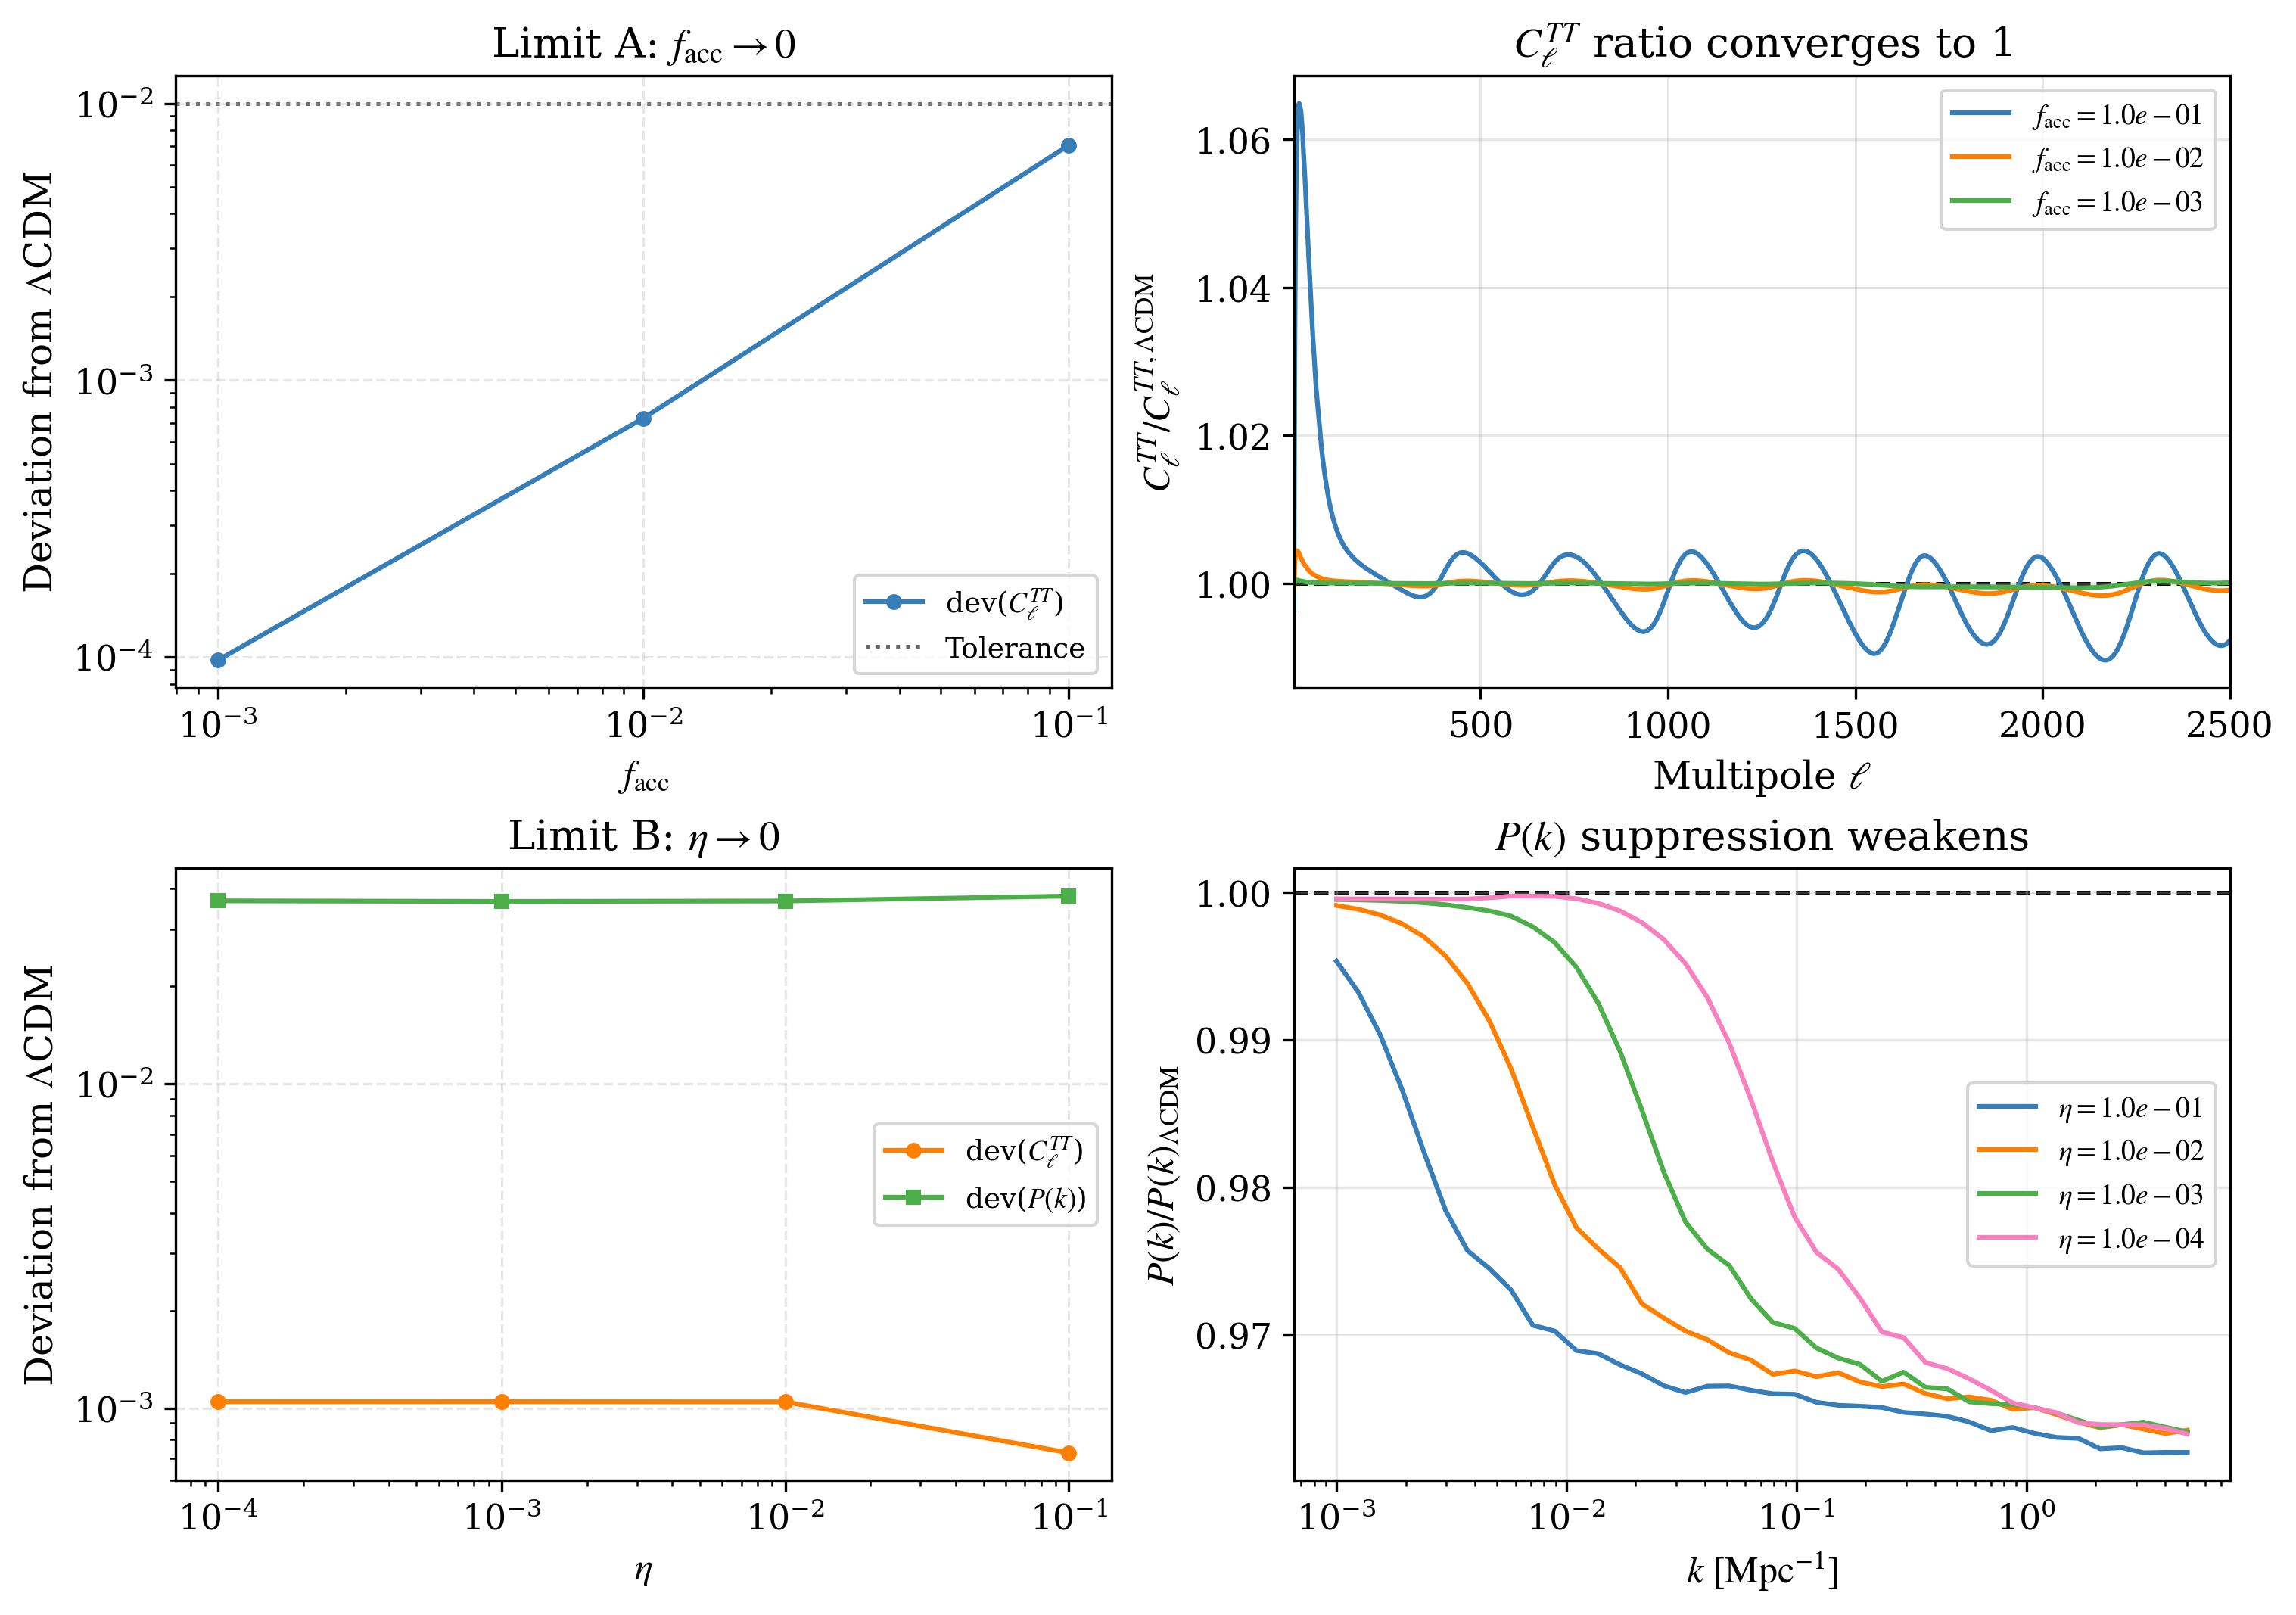

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "mathtext.fontset": "stix",   # Good serif math font
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,       # Thicker lines for visibility
    "figure.dpi": 300             # Minimum recommended resolution for print
})

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# ==============================================================================
# A1: deviation vs f_acc 
# ==============================================================================
ax = axes[0, 0]
ax.loglog(F_SEQ, cl_f, marker='o', color=qual_colors[0], markersize=4, label=r'dev($C_\ell^{TT}$)')
ax.axhline(TOL_A, color='dimgrey', linestyle=':', linewidth=1.2, label='Tolerance', zorder=1)

ax.set_xlabel(r'$f_{\mathrm{acc}}$')
ax.set_ylabel(r'Deviation from $\Lambda$CDM')
ax.set_title(r'Limit A: $f_{\mathrm{acc}} \rightarrow 0$')
ax.legend(loc='best')
ax.grid(True, which="major", linestyle="--", alpha=0.3) # Subtle grid helps track logs

# ==============================================================================
# A2: C_l TT ratio to LCDM
# ==============================================================================
ax = axes[0, 1]
for i, f in enumerate(F_SEQ[:5]):
    o = run_obs(accdm_params(f, 0.1), ('f', f))
    m = o['ell'] >= 2
    ax.plot(o['ell'][m], o['tt'][m] / ref['tt'][m], color=qual_colors[i], label=r'$f_{{\mathrm{{acc}}}} = {:.1e}$'.format(f))

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlim(2, LMAX)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$C_\ell^{TT} / C_\ell^{TT, \Lambda\mathrm{CDM}}$')
ax.set_title(r'$C_\ell^{TT}$ ratio converges to 1')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ==============================================================================
# B1: deviation vs eta
# ==============================================================================
ax = axes[1, 0]
ax.loglog(E_SEQ, cl_e, marker='o', color=qual_colors[1], markersize=4, label=r'dev($C_\ell^{TT}$)')
ax.loglog(E_SEQ, pk_e, marker='s', color=qual_colors[2], markersize=4, label=r'dev($P(k)$)')

ax.set_xlabel(r'$\eta$')
ax.set_ylabel(r'Deviation from $\Lambda$CDM')
ax.set_title(r'Limit B: $\eta \rightarrow 0$')
ax.legend(loc='best')
ax.grid(True, which="major", linestyle="--", alpha=0.3)

# ==============================================================================
# B2: P(k) ratio to LCDM 
# ==============================================================================
ax = axes[1, 1]
for i, e in enumerate(E_SEQ):
    o = run_obs(accdm_params(0.1, e), ('e', e))
    ax.semilogx(K_NODES, o['pk'] / ref['pk'], color=qual_colors[i], label=r'$\eta = {:.1e}$'.format(e))

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) / P(k)_{\Lambda\mathrm{CDM}}$')
ax.set_title(r'$P(k)$ suppression weakens')
ax.legend(loc='best')
ax.grid(True, which="major", alpha=0.3)

plt.show()

### Notes
- Limit A is the strong test (clean linear reduction). Limit B is a convergence test: a finite `eta` keeps a residual free-streaming suppression, so we only assert the trend, not an absolute floor.
